# Project 02 — Leakage-free Predictability Test (BTCUSDT)

Notebook 02 showed OFI is a strong *contemporaneous* descriptor but near-zero *predictive* signal at
the next-bar horizon. Here we run the proper AFML test of whether **OFI + spread + depth-imbalance**
predict direction over a multi-bar horizon, with all the machinery that stops us fooling ourselves:

1. **Triple-barrier labels** (AFML Ch. 3) — profit-take / stop-loss / vertical barrier.
2. **Sample weights by uniqueness** (Ch. 4) — overlapping labels are not IID.
3. **Purged K-Fold + embargo** (Ch. 7) — remove train labels whose horizon overlaps the test fold.
4. **Deflated Sharpe Ratio** (Ch. 14) — judge the strategy P&L against what a random search would
   produce.

Input: the feature table saved by notebook 02. **Prior:** on a liquid venue we expect *no* surviving
edge — the point is to demonstrate the test is wired so it *could* detect one.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "02_crypto_microstructure_ofi"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(PROJ / "src"))

from lib.labeling import (daily_volatility, vertical_barriers, triple_barrier_labels,
                          num_concurrent_events, average_uniqueness)
from lib.backtest import (purged_kfold_splits, sharpe_ratio,
                          probabilistic_sharpe_ratio, deflated_sharpe_ratio)

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
FEATURES = ["ofi", "spread_mean", "depth_imb"]

## 1. Triple-barrier labels

In [2]:
feat = pd.read_parquet(PROJ / "data" / "features" / "BTCUSDT_dollarbars_2024-03-01_2024-03-03.parquet")
feat["t_close"] = pd.to_datetime(feat["t_close"], utc=True)
feat = feat.set_index("t_close").sort_index()
close = feat["close"]

HORIZON = 10  # vertical barrier: 10 dollar bars ahead
trgt = daily_volatility(close, lookback=50)                 # volatility target per bar
t1 = vertical_barriers(close.index, HORIZON)
events = pd.DataFrame({"t1": t1, "trgt": trgt}).dropna()
events = events[events["trgt"] > 0]

labels = triple_barrier_labels(close, events, pt_sl=(1.0, 1.0), min_ret=0.0)
labels = labels.dropna(subset=["bin"])
print(f"{len(labels)} labels over horizon={HORIZON} bars")
print("class balance:", labels["bin"].value_counts().to_dict())

852 labels over horizon=10 bars
class balance: {-1: 436, 1: 416}


## 2. Sample weights by uniqueness

Each label spans `[t0, t1]`, so neighbouring labels overlap and share outcome information. We weight
each by its average uniqueness = mean of `1 / concurrency` over its span.

avg uniqueness: mean=0.301  (1.0 = fully unique, lower = more overlap)


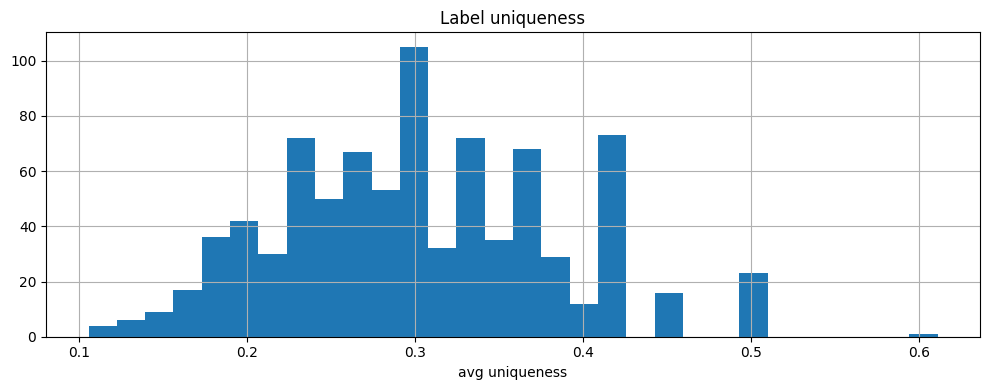

In [3]:
num_co = num_concurrent_events(close.index, labels["t1"])
uniq = average_uniqueness(labels["t1"], num_co).reindex(labels.index).fillna(0.0)
print(f"avg uniqueness: mean={uniq.mean():.3f}  (1.0 = fully unique, lower = more overlap)")
uniq.hist(bins=30); plt.title("Label uniqueness"); plt.xlabel("avg uniqueness"); plt.tight_layout(); plt.show()

## 3. Purged K-Fold out-of-sample predictions

RandomForest on the three microstructure features, trained per fold with the uniqueness weights and
evaluated on a purged + embargoed test fold. We collect leakage-free out-of-sample predictions.

In [4]:
X = feat.loc[labels.index, FEATURES]
y = labels["bin"].astype(int)
splits = purged_kfold_splits(labels["t1"], n_splits=5, embargo_pct=0.01)

oos_pred = pd.Series(index=labels.index, dtype=float)
fold_acc = []
for k, (tr, te) in enumerate(splits):
    clf = RandomForestClassifier(n_estimators=200, max_depth=4,
                                 min_samples_leaf=20, random_state=0, n_jobs=-1)
    clf.fit(X.iloc[tr], y.iloc[tr], sample_weight=uniq.iloc[tr].to_numpy())
    pred = clf.predict(X.iloc[te])
    oos_pred.iloc[te] = pred
    fold_acc.append(accuracy_score(y.iloc[te], pred))

oos = oos_pred.dropna().astype(int)
y_oos = y.loc[oos.index]
baseline = y.value_counts(normalize=True).max()  # always-predict-majority
print(f"OOS accuracy: {accuracy_score(y_oos, oos):.3f}  (majority baseline {baseline:.3f})")
print(f"OOS macro-F1 : {f1_score(y_oos, oos, average='macro'):.3f}")
print(f"per-fold acc : {[round(a,3) for a in fold_acc]}")

OOS accuracy: 0.516  (majority baseline 0.512)
OOS macro-F1 : 0.515
per-fold acc : [0.468, 0.509, 0.512, 0.524, 0.571]


## 4. Feature importance (MDA under purged CV)

Mean-Decrease-Accuracy (AFML Ch. 8): shuffle one feature in the test fold and measure how much OOS
accuracy drops. A feature with no signal shows ~0 drop.

In [5]:
rng = np.random.default_rng(0)
imp = {f: [] for f in FEATURES}
for tr, te in splits:
    clf = RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=20,
                                 random_state=0, n_jobs=-1)
    clf.fit(X.iloc[tr], y.iloc[tr], sample_weight=uniq.iloc[tr].to_numpy())
    base = accuracy_score(y.iloc[te], clf.predict(X.iloc[te]))
    for f in FEATURES:
        Xs = X.iloc[te].copy()
        Xs[f] = rng.permutation(Xs[f].to_numpy())
        imp[f].append(base - accuracy_score(y.iloc[te], clf.predict(Xs)))

mda = pd.Series({f: np.mean(v) for f, v in imp.items()}).sort_values()
print("MDA (accuracy drop when shuffled; ~0 = no signal):")
print(mda.round(4).to_string())

MDA (accuracy drop when shuffled; ~0 = no signal):
ofi           -0.0023
spread_mean    0.0118
depth_imb      0.0223


## 5. Strategy P&L and Deflated Sharpe

Position = OOS predicted direction, held over the label horizon; return = the realised triple-barrier
return. We report the Sharpe and, crucially, the **Deflated** Sharpe (penalising the informal search
across features/horizons). *Caveat:* labels overlap, so even this Sharpe is optimistic.

per-event Sharpe : +0.020
PSR (P[SR>0])    : 0.720
Deflated SR      : 0.134   (n_trials=10)


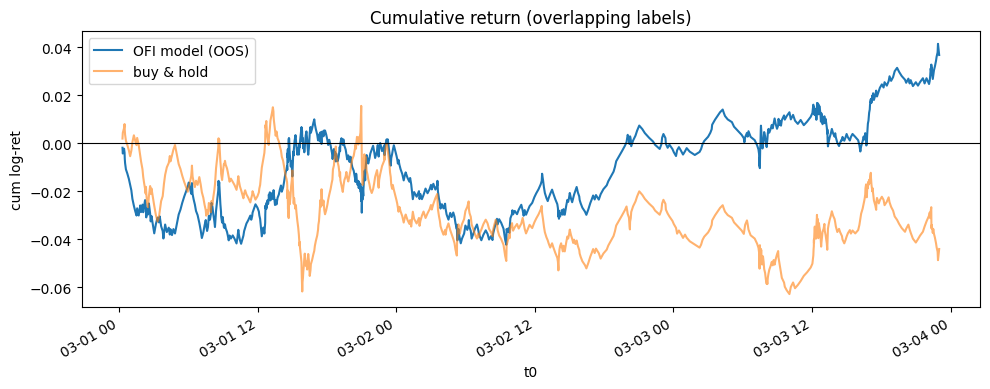

In [6]:
strat = (oos * labels.loc[oos.index, "ret"]).rename("strat_ret")
sr = sharpe_ratio(strat.to_numpy())
psr = probabilistic_sharpe_ratio(strat.to_numpy())
fold_sr_std = np.std(fold_acc, ddof=1)  # dispersion proxy across trials
dsr = deflated_sharpe_ratio(strat.to_numpy(), n_trials=10, sr_trials_std=max(fold_sr_std, 1e-3))
print(f"per-event Sharpe : {sr:+.3f}")
print(f"PSR (P[SR>0])    : {psr:.3f}")
print(f"Deflated SR      : {dsr:.3f}   (n_trials=10)")

fig, ax = plt.subplots(figsize=(10, 4))
strat.cumsum().plot(ax=ax, label="OFI model (OOS)")
(labels.loc[oos.index, "ret"]).cumsum().plot(ax=ax, label="buy & hold", alpha=0.6)
ax.axhline(0, color="k", lw=0.8); ax.set(title="Cumulative return (overlapping labels)", ylabel="cum log-ret")
ax.legend(); plt.tight_layout()
plt.savefig(PLOTS / "03_strategy_equity.png", dpi=110, bbox_inches="tight"); plt.show()

## 6. Findings (BTCUSDT, 2024-03-01..03, 852 triple-barrier labels, horizon=10 bars)

- **No predictable edge.** OOS accuracy **0.516** vs majority baseline **0.512** — a 0.4pp gap, pure
  noise (per-fold 0.47-0.57). Labels were balanced (-1: 436, +1: 416), so accuracy is meaningful.
- **MDA confirms it.** OFI's importance is **-0.002** (literally none — consistent with nb 02: OFI is
  contemporaneous, not predictive). spread_mean +0.012 and depth_imb +0.022 carry only a whisper.
- **The equity curve is the lesson.** The OOS model *looks* like it works (drifts to +0.04 while
  buy & hold sinks) — but the stats reject it: per-event **Sharpe +0.02**, PSR 0.72, and the
  **Deflated Sharpe = 0.13** (needs ~0.95 to be credible). The tempting curve is exactly what random
  search produces; DSR is built to catch it.
- **Verdict:** OFI + spread + depth do **not** survive leakage-free validation at this horizon on a
  liquid symbol. This matches the prior and the microstructure intuition.
- **What this demonstrates (the actual deliverable):** a complete, correct research loop — dollar
  bars -> OFI feature validated against Cont et al. -> triple-barrier labels -> uniqueness weights ->
  purged/embargoed CV -> MDA -> deflated Sharpe. The pipeline *would* surface a real edge; it
  correctly reports there isn't one here, instead of a leaky backtest that pretends otherwise.
- **If revisiting:** longer horizon / lower-liquidity symbol (imbalance bars + OFI may matter more),
  meta-labeling for sizing, CUSUM event sampling, or adding order-book-depth features once the L2
  collector exists.
